In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Task overview

![title](imgs/oil_production.png)

In this tasks it is suggested to you to predict oil well production performance. You have to use information about pressures and choke position to calculate amount of produced oil and water everyday for two production wells.

Your required to complete the following tasks:
- Preparation of data analysis
- Development of machine learning pipeline appropriate for that task including all necessary parts
- Experimentation with the tasks including not only regression, but also time-series approach and spatial dependencies (production from injection)

The main target of the actual task - prediction of variables **OIL_PROD** and **WAT_PROD**. Prediction of **GAS_PROD is not required**.

Since accurate prediction of amount of produced oil is more important than water it was suggested to have the following target metric. **Metric = 0.8*MAPE(OIL_TRUE, OIL_PRED) + 0.2*MAPE(WATER_TRUE, WATER_PRED)**

### Data overview

The dataset is relatively small, it contains only 4 wells from one of Norway sea oil fields and only two of them a oil producers (other two are injectors).
Each of production wells contains the following information:
- DATE - date of production
- WELLNAME - name of the well
- BHP - bottomhole pressure
- WHP - wellhead pressure
- CHOKE_1_PERC - percentage of the first choke openess
- CHOKE_2_PERC - percentage of the second choke openess
- OIL_PROD - volume of oil production
- GAS_PROD - volume of gas production
- WAT_PROD - volume of water production
- WAT_INJ - volume of injected water
- WELL_TYPE - type of the well (OP - oil production, WI - water injection)

In [8]:
train_data = pd.read_csv('/content/drive/MyDrive/expt/prod_data_train.csv')

In [9]:
def draw_well(df, name):
    plt.figure(dpi=100)
    for feat in ['BHP', 'WHP', 'CHOKE_1_PERC', 'CHOKE_2_PERC', 'OIL_PROD', 'GAS_PROD', 'WAT_PROD', 'WAT_INJ']:
        plt.plot(df[feat], label=feat)
    plt.yscale('log')
    plt.xticks(np.arange(df.DATE.shape[0])[::100], labels=df.DATE[::100], rotation=45, fontsize=6)
    plt.grid()
    plt.xlabel('Date')
    plt.legend(fontsize=5)
    plt.title('Well %s'%name)
    plt.plot()

Lets draw wells to see their dynamic.

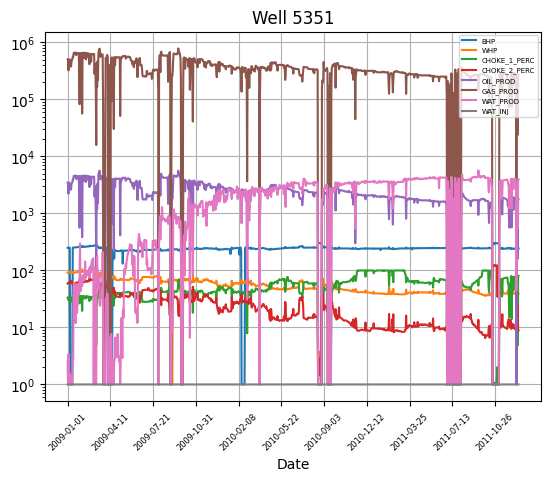

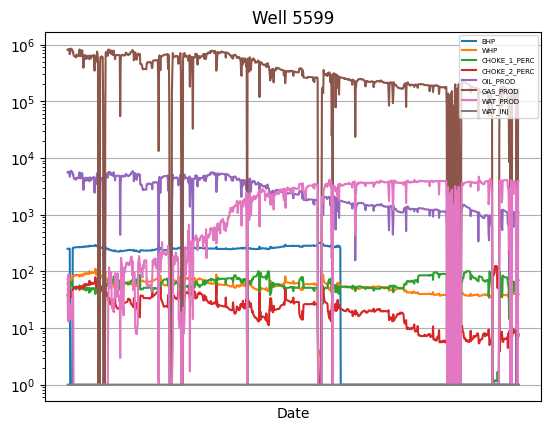

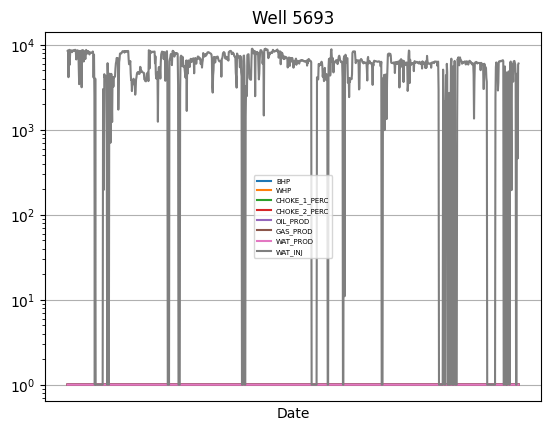

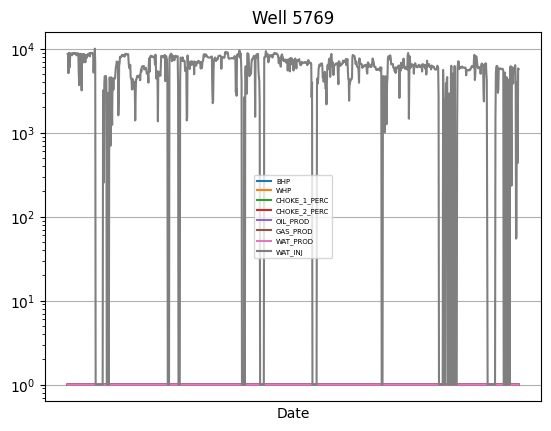

In [10]:
for well in train_data.WELLNAME.unique():
    draw_well(train_data[train_data.WELLNAME==well], well)

# Modelling  

#### Oil part

In [31]:
target_oil = 'OIL_PROD'
# features = ['BHP', 'WHP', 'CHOKE_1_PERC', 'CHOKE_2_PERC']
features = ['BHP', 'WHP', 'CHOKE_1_PERC', 'CHOKE_2_PERC', 'WAT_INJ']

In [32]:
X_train, X_val, y_train, y_val = train_test_split(train_data[features], train_data[target_oil], test_size=0.2, random_state=42)

In [33]:
regressor_oil = RandomForestRegressor(random_state=42)
regressor_oil.fit(X_train, y_train)
prediction_oil = regressor_oil.predict(X_val)
score_oil = mean_absolute_percentage_error(y_val, prediction_oil)
print('Score for %s feature is %.4f'%(target_oil, score_oil))

Score for OIL_PROD feature is 0.3910


#### Water part

In [34]:
target_wat = 'WAT_PROD'

In [35]:
X_train, X_val, y_train, y_val = train_test_split(train_data[features], train_data[target_wat], test_size=0.2, random_state=42)

In [36]:
regressor_wat = RandomForestRegressor(random_state=42)
regressor_wat.fit(X_train, y_train)
prediction_wat = regressor_wat.predict(X_val)
score_wat = mean_absolute_percentage_error(y_val, prediction_wat)
print('Score for %s feature is %.4f'%(target_wat, score_wat))

Score for WAT_PROD feature is 1.6239


# Evaluation

In [37]:
overall_metric = score_oil*0.8 + score_wat*0.2

In [38]:
print('Overall solution metric is %.4f'%(overall_metric))

Overall solution metric is 0.6376


# Blind Test

### Test data

In [39]:
test_data = pd.read_csv('/content/drive/MyDrive/expt/prod_data_test_CANDIDATE.csv')

In [40]:
production_part = test_data[test_data.WELLNAME.isin([5351, 5599])]

In [41]:
production_part.loc[:, 'OIL_PROD'] = regressor_oil.predict(production_part[features])
production_part.loc[:, 'WAT_PROD'] = regressor_wat.predict(production_part[features])

In [42]:
name = 'Candidate'
production_part.to_csv('%s_prediction.csv'%name, index=None)

In this case proposed solution is a simple regression, but we would like to encouruage you to exploit not only different models but also different approaches (e.g. as time series) and try to find a way to use injection data.